In [32]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import clear_output
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.circuit.library import RealAmplitudes, ZZFeatureMap
from qiskit_algorithms.optimizers import COBYLA, L_BFGS_B
from qiskit_algorithms.utils import algorithm_globals

from qiskit_machine_learning.algorithms.classifiers import NeuralNetworkClassifier, VQC
from qiskit_machine_learning.algorithms.regressors import NeuralNetworkRegressor, VQR
from qiskit_machine_learning.neural_networks import SamplerQNN, EstimatorQNN
from qiskit_machine_learning.circuit.library import QNNCircuit

In [33]:
# Load the dataset from CSV
df = pd.read_csv('C:/Users/IITIEE/Desktop/SOUMEN DAS/Data_set/USA_Housing.csv')
print(df.head())

   Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
0      79545.458574             5.682861                   7.009188   
1      79248.642455             6.002900                   6.730821   
2      61287.067179             5.865890                   8.512727   
3      63345.240046             7.188236                   5.586729   
4      59982.197226             5.040555                   7.839388   

   Avg. Area Number of Bedrooms  Area Population         Price  \
0                          4.09     23086.800503  1.059034e+06   
1                          3.09     40173.072174  1.505891e+06   
2                          5.13     36882.159400  1.058988e+06   
3                          3.26     34310.242831  1.260617e+06   
4                          4.23     26354.109472  6.309435e+05   

                                             Address  
0  208 Michael Ferry Apt. 674\nLaurabury, NE 3701...  
1  188 Johnson Views Suite 079\nLake Kathleen, CA...  
2  9127 Eli

In [34]:
df.drop(['Address'], axis = 1 ,inplace=True)
print(df)

      Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
0         79545.458574             5.682861                   7.009188   
1         79248.642455             6.002900                   6.730821   
2         61287.067179             5.865890                   8.512727   
3         63345.240046             7.188236                   5.586729   
4         59982.197226             5.040555                   7.839388   
...                ...                  ...                        ...   
4995      60567.944140             7.830362                   6.137356   
4996      78491.275435             6.999135                   6.576763   
4997      63390.686886             7.250591                   4.805081   
4998      68001.331235             5.534388                   7.130144   
4999      65510.581804             5.992305                   6.792336   

      Avg. Area Number of Bedrooms  Area Population         Price  
0                             4.09     2308

In [35]:
from sklearn.preprocessing import MinMaxScaler
print(df)
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df.to_numpy())
df_scaled = pd.DataFrame(df_scaled, columns=[
  'Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms', 'Avg. Area Number of Bedrooms','Area Population','Price'])
 
print("Scaled Dataset Using MinMaxScaler")
df_scaled.head()

features = MinMaxScaler().fit_transform(df_scaled)
print(features)

      Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
0         79545.458574             5.682861                   7.009188   
1         79248.642455             6.002900                   6.730821   
2         61287.067179             5.865890                   8.512727   
3         63345.240046             7.188236                   5.586729   
4         59982.197226             5.040555                   7.839388   
...                ...                  ...                        ...   
4995      60567.944140             7.830362                   6.137356   
4996      78491.275435             6.999135                   6.576763   
4997      63390.686886             7.250591                   4.805081   
4998      68001.331235             5.534388                   7.130144   
4999      65510.581804             5.992305                   6.792336   

      Avg. Area Number of Bedrooms  Area Population         Price  
0                             4.09     2308

In [36]:
mean=df_scaled["Price"].mean()
print("mean of price \n",mean)

mean of price 
 0.4957484988842136


In [37]:
cutoff =mean                            # Decide on a cutoff limit
print(cutoff)
df_scaled['Buys House(class Label)'] = [0 if x > cutoff else 1 for x in df_scaled['Price']]
print(df_scaled)

0.4957484988842136
      Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
0             0.686822             0.441986                   0.501502   
1             0.683521             0.488538                   0.464501   
2             0.483737             0.468609                   0.701350   
3             0.506630             0.660956                   0.312430   
4             0.469223             0.348556                   0.611851   
...                ...                  ...                        ...   
4995          0.475738             0.754359                   0.385619   
4996          0.675097             0.633450                   0.444024   
4997          0.507135             0.670026                   0.208534   
4998          0.558419             0.420389                   0.517579   
4999          0.530715             0.486997                   0.472678   

      Avg. Area Number of Bedrooms  Area Population     Price  \
0                         0

In [38]:
X = df_scaled[['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
               'Avg. Area Number of Bedrooms', 'Area Population','Price']]
print(X)
y = df_scaled['Buys House(class Label)']
print(y)

      Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
0             0.686822             0.441986                   0.501502   
1             0.683521             0.488538                   0.464501   
2             0.483737             0.468609                   0.701350   
3             0.506630             0.660956                   0.312430   
4             0.469223             0.348556                   0.611851   
...                ...                  ...                        ...   
4995          0.475738             0.754359                   0.385619   
4996          0.675097             0.633450                   0.444024   
4997          0.507135             0.670026                   0.208534   
4998          0.558419             0.420389                   0.517579   
4999          0.530715             0.486997                   0.472678   

      Avg. Area Number of Bedrooms  Area Population     Price  
0                         0.464444         0.32

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from qiskit_algorithms.utils import algorithm_globals

#X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=101)
# Building the Linear Regression Model
model = LinearRegression()
print("Training data =\n",X)
print("type =\n",type(X))
print("Training label=\n",y)
# Fitting the model on the training data
model.fit(X, y)

Training data =
       Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
0             0.686822             0.441986                   0.501502   
1             0.683521             0.488538                   0.464501   
2             0.483737             0.468609                   0.701350   
3             0.506630             0.660956                   0.312430   
4             0.469223             0.348556                   0.611851   
...                ...                  ...                        ...   
4995          0.475738             0.754359                   0.385619   
4996          0.675097             0.633450                   0.444024   
4997          0.507135             0.670026                   0.208534   
4998          0.558419             0.420389                   0.517579   
4999          0.530715             0.486997                   0.472678   

      Avg. Area Number of Bedrooms  Area Population     Price  
0                         0.46

LinearRegression()

In [40]:
from sklearn import metrics
from sklearn.metrics import classification_report, confusion_matrix

print("X_test data =\n",X)
y_pred = model.predict(X)
#print("Y_Test data\n",y_test,"\n")
print("y_predict data =\n",y_pred,"\n")

X_test data =
       Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
0             0.686822             0.441986                   0.501502   
1             0.683521             0.488538                   0.464501   
2             0.483737             0.468609                   0.701350   
3             0.506630             0.660956                   0.312430   
4             0.469223             0.348556                   0.611851   
...                ...                  ...                        ...   
4995          0.475738             0.754359                   0.385619   
4996          0.675097             0.633450                   0.444024   
4997          0.507135             0.670026                   0.208534   
4998          0.558419             0.420389                   0.517579   
4999          0.530715             0.486997                   0.472678   

      Avg. Area Number of Bedrooms  Area Population     Price  
0                         0.4644

In [41]:
from sklearn import metrics
from sklearn.metrics import classification_report, confusion_matrix
print("Y_Test data\n",y,"\n")
print("predicted data\n",y_pred,"\n")

Y_Test data
 0       1
1       0
2       1
3       0
4       1
       ..
4995    1
4996    0
4997    1
4998    1
4999    0
Name: Buys House(class Label), Length: 5000, dtype: int64 

predicted data
 [0.70869853 0.18882656 0.70834285 ... 0.71561656 0.54418881 0.42190906] 



In [42]:
from sklearn import metrics
from sklearn.metrics import classification_report, confusion_matrix

y_pred_classes = np.zeros_like(y_pred)    # initialise a matrix full with zeros
y_pred_classes[y_pred > cutoff] = 1       # add a 1 if the cutoff was breached
print("\n class label for y_pred_classes=\n",y_pred_classes)

cnf=confusion_matrix(y, y_pred_classes)
print("confusion matrix =\n",cnf)


TN,FP, FN, TP = cnf.ravel()
print("\n")
print("No of TN =",TN)
print("No of FP =",FP)
print("No of FN =",FN)
print("No of TP =",TP)


 class label for y_pred_classes=
 [1. 0. 1. ... 1. 1. 0.]
confusion matrix =
 [[2480   23]
 [   4 2493]]


No of TN = 2480
No of FP = 23
No of FN = 4
No of TP = 2493


In [43]:
No_features=X.max(axis=0)
#No_qubits=len(No_features)
No_qubits=1
print("No of qubits required=", No_qubits)

No of qubits required= 1


C:\Users\IITIEE\AppData\Roaming\Python\Python311\site-packages\qiskit\visualization\circuit\matplotlib.py:266: FutureWarning: The default matplotlib drawer scheme will be changed to "iqp" in a following release. To silence this warning, specify the current default explicitly as style="clifford", or the new default as style="iqp".
  self._style, def_font_ratio = load_style(self._style)


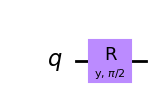

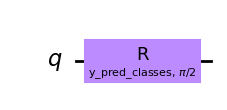

In [44]:
# construct simple feature map
param_y = Parameter("y")
feature_map = QuantumCircuit(No_qubits, name="fm")
#for i in range(0,No_qubits):
feature_map.ry(param_y, 0)
display(feature_map.decompose().draw(output="mpl", fold=20))
# construct simple ansatz
param_y_pred_classes = Parameter("y_pred_classes")
ansatz = QuantumCircuit(No_qubits, name="vf")
#for j in range(0,No_qubits):
ansatz.ry(param_y_pred_classes, 0)
display(ansatz.decompose().draw(output="mpl", fold=20))

# construct a circuit
qc = QNNCircuit(feature_map=feature_map, ansatz=ansatz)
# construct QNN
regression_estimator_qnn = EstimatorQNN(circuit=qc)
print(regression_estimator_qnn)



In [45]:
# callback function that draws a live plot when the .fit() method is called
def callback_graph(weights, obj_func_eval):
    print(weights)
    clear_output(wait=True)
    objective_func_vals.append(obj_func_eval)
    plt.title("Objective function value against iteration")
    plt.xlabel("Iteration")
    plt.ylabel("Objective function value")
    plt.plot(range(len(objective_func_vals)), objective_func_vals)
    plt.show()

In [46]:
num_iter=int(input("please enter the iteration number ="))

please enter the iteration number = 500


In [47]:
# construct the regressor from the neural network
regressor = NeuralNetworkRegressor(
    neural_network=regression_estimator_qnn,
    loss="squared_error",
    optimizer=COBYLA(maxiter=num_iter),
    callback=callback_graph,
)

In [48]:
print(type(y))
print(type(y_pred_classes))

<class 'pandas.core.series.Series'>
<class 'numpy.ndarray'>


In [49]:
#convert <class 'pandas.core.frame.DataFrame'> to  <class 'numpy.ndarray'>
df = pd.DataFrame(y)
y = df.to_numpy()
print("type y=",type(y))


type y= <class 'numpy.ndarray'>


In [50]:
#print(y)
print(len(y))
#print(y_pred_classes)
print(len(y_pred_classes))

5000
5000


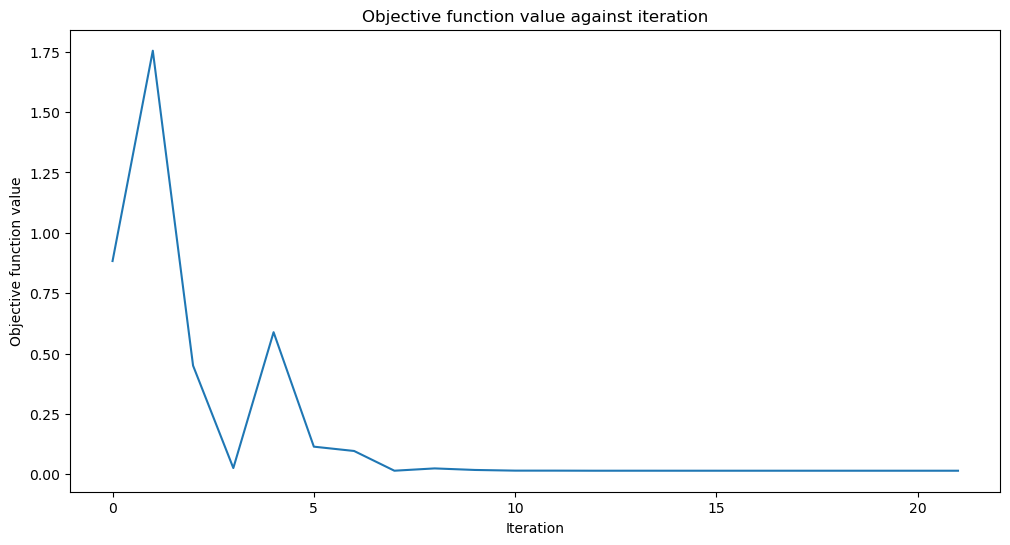

Training time: 334 seconds
regressor score= 0.9418482592212768


In [51]:
import time
# create empty array for the callback to store evaluations of the objective function
objective_func_vals = []
plt.rcParams["figure.figsize"] = (12, 6)

start = time.time()
regressor.fit(y,y_pred_classes)# fit to data
elapsed = time.time() - start
print(f"Training time: {round(elapsed)} seconds")

# return to default figsize
plt.rcParams["figure.figsize"] = (6, 4)

# score the result
regressor_score=regressor.score(y,y_pred_classes)
print("regressor score=",regressor_score)


In [78]:
X_test = df_scaled['Avg. Area Income']
print(type(X_test))
#convert <class 'pandas.core.frame.DataFrame'> to  <class 'numpy.ndarray'>
df = pd.DataFrame(X_test)
X_test= df.to_numpy()
print("type X_test=",type(X_test))

#y_test= df_scaled['Buys House(class Label)']
y_test= df_scaled['Price']
print(type(y_test))
df_1= pd.DataFrame(y_test)
y_test= df.to_numpy()
print("type y=",type(y_test))

print(type(y_pred))

<class 'pandas.core.series.Series'>
type X_test= <class 'numpy.ndarray'>
<class 'pandas.core.series.Series'>
type y= <class 'numpy.ndarray'>
<class 'numpy.ndarray'>


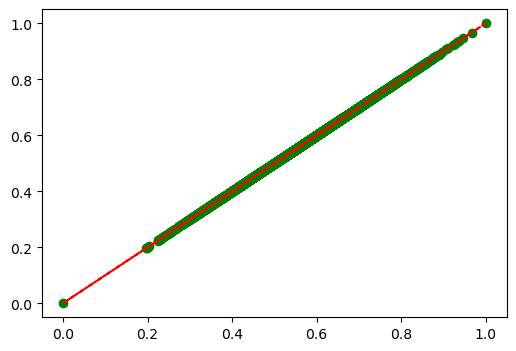

In [112]:
# plot target function before prediction 
plt.plot(X_test,y_test, "go")
plt.plot(X_test, y_test, "r--")
plt.show()

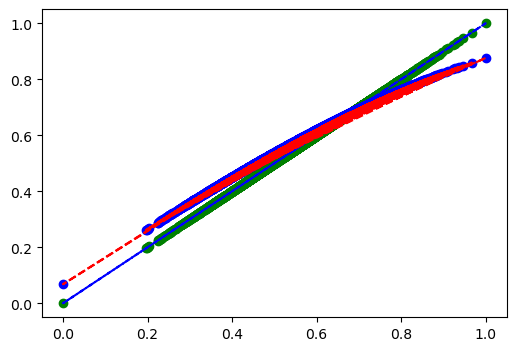

In [111]:
# plot target function  before prediction
plt.plot(X_test,y_test, "go") # plot data X_test,y_tes
plt.plot(X_test, y_test, "b--")# plot fitted line

#after prediction
plt.plot(X_test, y_pred, "bo")# plot data X_test, y_pred
plt.plot(X_test, y_pred, "r--")# plot fitted line
plt.show()

In [90]:
#print(type(X))

New_Avg_Area_Income=[0.5850,0.6447,0.4785,0.3974] # unknown/new data for validation testing

New_Avg_Area_Income= np.asarray(New_Avg_Area_Income)
New_Avg_Area_Income=New_Avg_Area_Income.reshape(len(New_Avg_Area_Income), 1)

#print(type(New_Avg_Area_Income))

predicted_price=regressor.predict(New_Avg_Area_Income)
#print(predicted_price)

for i in range(0,len(New_Avg_Area_Income)):
    for j in range(i,len(predicted_price)):
        print("predicted price of lot_size ",New_Avg_Area_Income[i],"is=",predicted_price[j])
        break

predicted price of lot_size  [0.585] is= [0.60755017]
predicted price of lot_size  [0.6447] is= [0.65385824]
predicted price of lot_size  [0.4785] is= [0.51967679]
predicted price of lot_size  [0.3974] is= [0.44875581]
